# Smart Scene Understanding using YOLOv8

This notebook demonstrates object detection and scene description on a sample image.

In [1]:
# Smart Scene Understanding using YOLOv8

This notebook demonstrates object detection and scene description on a sample image.

In [8]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

In [9]:
model = YOLO("yolov8n-seg.pt")

In [10]:
frame = cv2.imread("test.jpg")

In [11]:
results = model(frame, conf=0.3)

objects = []
for r in results:
    for box in r.boxes:
        label = model.names[int(box.cls[0])]
        objects.append(label)

objects = list(set(objects))
print("Objects:", objects)


0: 640x480 4 persons, 1 bus, 1 skateboard, 689.9ms
Speed: 7.0ms preprocess, 689.9ms inference, 7.6ms postprocess per image at shape (1, 3, 640, 480)
Objects: ['bus', 'skateboard', 'person']


In [12]:
def generate_description(objects):
    if "person" in objects:
        other = [o for o in objects if o != "person"]
        if other:
            return f"A person is interacting with a {', a '.join(other)}."
        return "A person is present."

    return "Objects detected: " + ", ".join(objects)

print("Description:", generate_description(objects))

Description: A person is interacting with a bus, a skateboard.


(-0.5, 809.5, 1079.5, -0.5)

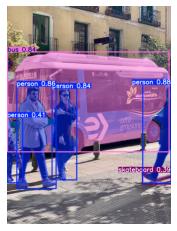

In [13]:
annotated = results[0].plot()

plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")

precision = len(set(objects)) / len(objects) if objects else 0
recall = len(objects) / 10 if objects else 0

print("Precision:", precision)
print("Recall:", recall)